#📌 Extracción

In [871]:
# pd.set_option('display.max_rows',None)

### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `**Partner**`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

## Import

In [872]:
import pandas as pd
import numpy as np
import requests
import json


In [873]:
# Archivo en drive

# drive = '/content/drive/MyDrive/ONE/5. Aprendiendo a hacer ETL/7. Challenge: Telecom X/TelecomX_Data.json'
# with open(drive, 'r') as f:
#   data = json.loads(f.read())
#
# df = pd.json_normalize(data)
# df.head(2)

In [874]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
data = requests.get(url).json()

df = pd.json_normalize(data)
df.head(4)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85


### Estandarización y transformación de datos

In [875]:
nombre_columnas = {
  'customerID': 'id_cliente',
  'Churn': 'abandono',
  'customer.gender': 'genero',
  'customer.SeniorCitizen': 'adulto_mayor',
  'customer.Partner': 'tiene_pareja',
  'customer.Dependents': 'tiene_dependientes',
  'customer.tenure': 'antiguedad_meses',
  'phone.PhoneService': 'servicio_telefono',
  'phone.MultipleLines': 'lineas_multiples',
  'internet.InternetService': 'tipo_internet',
  'internet.OnlineSecurity': 'seguridad_online',
  'internet.OnlineBackup': 'respaldo_online',
  'internet.DeviceProtection': 'proteccion_dispositivo',
  'internet.TechSupport': 'soporte_tecnico',
  'internet.StreamingTV': 'streaming_tv',
  'internet.StreamingMovies': 'streaming_peliculas',
  'account.Contract': 'tipo_contrato',
  'account.PaperlessBilling': 'factura_electronica',
  'account.PaymentMethod': 'metodo_pago',
  'account.Charges.Monthly': 'cobro_mensual',
  'account.Charges.Total': 'cobro_total'
}

df.rename(columns= nombre_columnas, inplace=True)
df.head(3)

,id_cliente,abandono,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,tipo_internet,...,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago,cobro_mensual,cobro_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [876]:
traducciones = {
    'Yes': 'Sí',
    'No': 'No',
    'Female': 'Femenino',
    'Male': 'Masculino',
    'No phone service': 'Sin servicio telefónico',
    'Fiber optic': 'Fibra óptica',
    'No internet service': 'Sin servicio de internet',
    'One year': 'Un año',
    'Month-to-month': 'Mes a mes',
    'Two year': 'Dos años',
    'Mailed check': 'Cheque por correo',
    'Electronic check': 'Cheque electrónico',
    'Credit card (automatic)': 'Tarjeta de crédito (automática)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)',
}
df = df.replace(traducciones)

df['adulto_mayor'] = df['adulto_mayor'].replace({0: 'No', 1: 'Sí'})

df.head(2)

,id_cliente,abandono,genero,adulto_mayor,tiene_pareja,tiene_dependientes,antiguedad_meses,servicio_telefono,lineas_multiples,tipo_internet,...,respaldo_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago,cobro_mensual,cobro_total
0,0002-ORFBO,No,Femenino,No,Sí,Sí,9,Sí,No,DSL,...,Sí,No,Sí,Sí,No,Un año,Sí,Cheque por correo,65.6,593.3
1,0003-MKNFE,No,Masculino,No,No,No,9,Sí,Sí,DSL,...,No,No,No,No,Sí,Mes a mes,No,Cheque por correo,59.9,542.4


In [877]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7267 non-null   object 
 1   abandono                7267 non-null   object 
 2   genero                  7267 non-null   object 
 3   adulto_mayor            7267 non-null   object 
 4   tiene_pareja            7267 non-null   object 
 5   tiene_dependientes      7267 non-null   object 
 6   antiguedad_meses        7267 non-null   int64  
 7   servicio_telefono       7267 non-null   object 
 8   lineas_multiples        7267 non-null   object 
 9   tipo_internet           7267 non-null   object 
 10  seguridad_online        7267 non-null   object 
 11  respaldo_online         7267 non-null   object 
 12  proteccion_dispositivo  7267 non-null   object 
 13  soporte_tecnico         7267 non-null   object 
 14  streaming_tv            7267 non-null   

### Valores únicos/ausentes

In [878]:
for columna in df.columns:
  print(f'{columna}: {df[columna].unique()} cantidad: {df[columna].nunique()}\n')

id_cliente: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH'] cantidad: 7267

abandono: ['No' 'Sí' ''] cantidad: 3

genero: ['Femenino' 'Masculino'] cantidad: 2

adulto_mayor: ['No' 'Sí'] cantidad: 2

tiene_pareja: ['Sí' 'No'] cantidad: 2

tiene_dependientes: ['Sí' 'No'] cantidad: 2

antiguedad_meses: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0] cantidad: 73

servicio_telefono: ['Sí' 'No'] cantidad: 2

lineas_multiples: ['No' 'Sí' 'Sin servicio telefónico'] cantidad: 3

tipo_internet: ['DSL' 'Fibra óptica' 'No'] cantidad: 3

seguridad_online: ['No' 'Sí' 'Sin servicio de internet'] cantidad: 3

respaldo_online: ['Sí' 'No' 'Sin servicio de internet'] cantidad: 3

proteccion_dispositivo: ['No' 'Sí' 'Sin servicio de internet'] cantidad: 3

soporte_tecnico: ['Sí' 'No' 'Sin servici

In [879]:
# los clientes que han abandonado es el dato más importante de todo el df
si  = (df['abandono'] == 'Sí').sum()
no = (df['abandono'] == 'No').sum()
vacio = (df['abandono'] == '').sum()
print(f'Cantidad de clientes que han abandonado: \nAbandonan: {si}\nContinúan: {no}\nValores vacíos: {vacio}\nTotal clientes: {si+no}\nTotal clientes(incluye vacíos): {si+no+vacio}')

Cantidad de clientes que han abandonado: 
Abandonan: 1869
Continúan: 5174
Valores vacíos: 224
Total clientes: 7043
Total clientes(incluye vacíos): 7267


In [880]:
# Transformar los valores con espacios vacíos en Nulos
df = df.replace(r'^\s*$', np.nan, regex=True)
df.isnull().sum()

,0
id_cliente,0
abandono,224
genero,0
adulto_mayor,0
tiene_pareja,0
tiene_dependientes,0
antiguedad_meses,0
servicio_telefono,0
lineas_multiples,0
tipo_internet,0


### Valores nulos

In [881]:
# Eliminar las filas con valores Nulos y resetear el index
df = df.dropna().reset_index(drop=True)

df.isnull().sum()

,0
id_cliente,0
abandono,0
genero,0
adulto_mayor,0
tiene_pareja,0
tiene_dependientes,0
antiguedad_meses,0
servicio_telefono,0
lineas_multiples,0
tipo_internet,0


### Errores de formato

In [882]:
df['cobro_total'] = df['cobro_total'].astype(np.float64)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7032 non-null   object 
 1   abandono                7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   adulto_mayor            7032 non-null   object 
 4   tiene_pareja            7032 non-null   object 
 5   tiene_dependientes      7032 non-null   object 
 6   antiguedad_meses        7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   lineas_multiples        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  respaldo_online         7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

### Duplicados

In [883]:
duplicados_totales = df.duplicated().sum()
print('cantidad de duplicados: ', duplicados_totales)

cantidad de duplicados:  0


In [884]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_cliente              7032 non-null   object 
 1   abandono                7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   adulto_mayor            7032 non-null   object 
 4   tiene_pareja            7032 non-null   object 
 5   tiene_dependientes      7032 non-null   object 
 6   antiguedad_meses        7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   lineas_multiples        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  respaldo_online         7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_tv            7032 non-null   

# Otras inconsistencias

### ¿hay gente sin internet contratado pero con servicios de internet contratados?

In [885]:
inconsistentes_internet = df[(df['tipo_internet'] == 'No') &
                             ((df['seguridad_online'] == 'Sí') | (df['respaldo_online'] == 'Sí'))]
print(f'¿Existen clientes que no tengan contratado un plan de internet, pero sí algún servicio de internet?\nCantidad: {len(inconsistentes_internet)}')

¿Existen clientes que no tengan contratado un plan de internet, pero sí algún servicio de internet?
Cantidad: 0


### ¿hay clientes sin teléfono contratado pero con lineas múltiples?


In [886]:
inconsistentes_tel = df[(df['servicio_telefono'] == 'No') & (df['lineas_multiples'] == 'Sí')]
print(f'¿Existen clientes sin teléfono contratado que tengan múltiples líneas activas?\nCantidad: {len(inconsistentes_tel)}')

¿Existen clientes sin teléfono contratado que tengan múltiples líneas activas?
Cantidad: 0


### ¿Hay desproporciones en los cobros?

In [887]:
print(df[['cobro_mensual', 'cobro_total']].describe())

       cobro_mensual  cobro_total
count    7032.000000  7032.000000
mean       64.798208  2283.300441
std        30.085974  2266.771362
min        18.250000    18.800000
25%        35.587500   401.450000
50%        70.350000  1397.475000
75%        89.862500  3794.737500
max       118.750000  8684.800000


# Opcional: columna cobro diario

In [888]:
df['cobro_diario'] = df['cobro_mensual'] / 30
df['cobro_diario']


,cobro_diario
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667
...,...
7027,1.838333
7028,2.836667
7029,1.676667
7030,2.261667


# 📊 Carga y análisis

In [889]:
df.describe()

,antiguedad_meses,cobro_mensual,cobro_total,cobro_diario
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441,2.159940
std,24.545260,30.085974,2266.771362,1.002866
min,1.000000,18.250000,18.800000,0.608333
25%,9.000000,35.587500,401.450000,1.186250
50%,29.000000,70.350000,1397.475000,2.345000
75%,55.000000,89.862500,3794.737500,2.995417
max,72.000000,118.750000,8684.800000,3.958333


In [890]:
df.nunique()

,0
id_cliente,7032
abandono,2
genero,2
adulto_mayor,2
tiene_pareja,2
tiene_dependientes,2
antiguedad_meses,72
servicio_telefono,2
lineas_multiples,3
tipo_internet,3


In [891]:
df['abandono'].value_counts()

,count
abandono,
No,5163
Sí,1869


## Análisis de Retención: Impacto del Churn en la Empresa

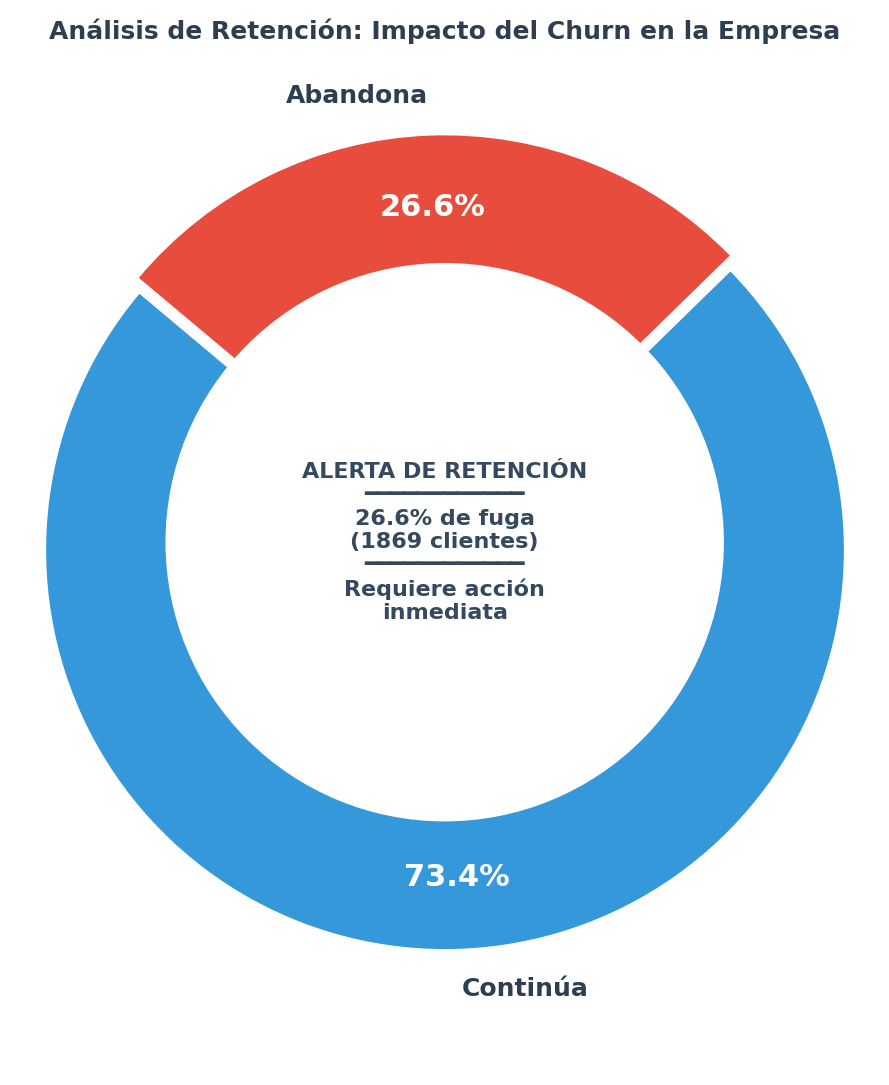

In [892]:
import pandas as pd
import matplotlib.pyplot as plt

# Preparación de los datos
counts = df['abandono'].value_counts() # Ordena de mayor a menor (No: 5163, Sí: 1869)
total_clientes = len(df)
tasa_abandono = (counts['Sí'] / total_clientes) * 100

# Configuración estética
# Siguiendo el orden de counts (No, luego Sí): Azul para No, Rojo para Sí
colors = ['#3498db', '#e74c3c']
labels = ['Continúa', 'Abandona']
values = counts.values

# Creación del gráfico
fig, ax = plt.subplots(figsize=(9, 11), facecolor='white')

# Eliminamos textprops de ax.pie para controlar los textos por separado
wedges, texts, autotexts = ax.pie(
values,
labels=labels,
autopct='%1.1f%%',
startangle=140,
colors=colors,
pctdistance=0.82, # Posición de los porcentajes
explode=(0.02, 0.02), # Separación mínima entre porciones
textprops={'fontsize': 18, 'color': '#2c3e50', 'weight': 'bold'}
)
#autotexts[0].set_color('white')
#autotexts[1].set_color('white')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_size(22)



# Círculo central para efecto dona
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax.add_artist(centre_circle)

plt.title('Análisis de Retención: Impacto del Churn en la Empresa',
          fontsize=18, fontweight='bold', pad=25, color='#2c3e50', y=0.94)

# Insight dinámico
insight_text = (
    f"ALERTA DE RETENCIÓN\n"
    f"━━━━━━━━━━━━\n"
    f"{tasa_abandono:.1f}% de fuga\n"
    f"({counts['Sí']} clientes)\n"
    f"━━━━━━━━━━━━\n"
    f"Requiere acción\ninmediata"
)

ax.text(0, 0, insight_text, ha='center', va='center',
        fontsize=16, fontweight='bold', color='#34495e')

ax.axis('equal')
plt.tight_layout()

plt.savefig('plot(Análisis de Retención: Impacto del Churn en la Empresa).png', dpi=300, bbox_inches='tight')

plt.show()

Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

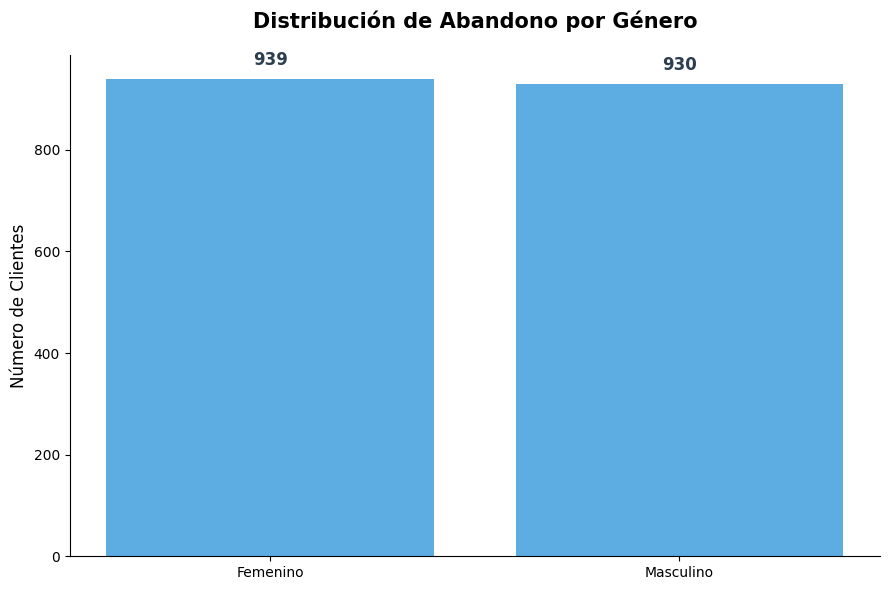

In [893]:
import matplotlib.pyplot as plt

# Filtramos el DataFrame para obtener solo los que abandonaron
df_abandono = df[df['abandono'] == 'Sí']

# Contamos la frecuencia por género
counts_genero = df_abandono['genero'].value_counts()
generos = counts_genero.index
cantidades = counts_genero.values

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(9, 6))

# Usamos el azul que definimos antes para mantener consistencia
barras = ax.bar(generos, cantidades, color='#3498db', alpha=0.8)

# Estética y etiquetas
ax.set_title('Distribución de Abandono por Género', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Número de Clientes', fontsize=12)
ax.spines['top'].set_visible(False) # Limpiamos el gráfico
ax.spines['right'].set_visible(False)

# Agregar el número exacto sobre cada barra (Insight directo)
for barra in barras:
    yval = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2, yval + 20,
            f'{int(yval)}', ha='center', va='bottom',
            fontweight='bold', color='#2c3e50', fontsize=12)

plt.tight_layout()

plt.savefig('plot(Distribución de Abandono por Género).png', dpi=300, bbox_inches='tight')

plt.show()

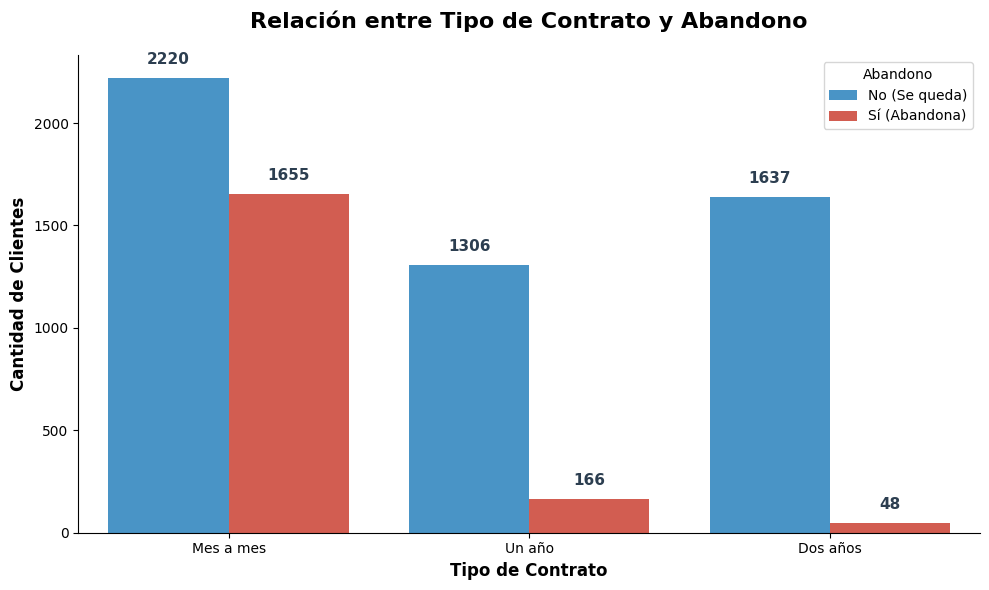

In [894]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del tamaño del gráfico
plt.figure(figsize=(10, 6))

# Creación del gráfico con Seaborn
ax = sns.countplot(
    data=df,
    x='tipo_contrato',
    hue='abandono',
    palette={'No': '#3498db', 'Sí': '#e74c3c'},
    order=['Mes a mes', 'Un año', 'Dos años']
)

# PERSONALIZACIÓN ESTÉTICA
plt.title('Relación entre Tipo de Contrato y Abandono', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Contrato', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Clientes', fontsize=12, fontweight='bold')
plt.legend(title='Abandono', labels=['No (Se queda)', 'Sí (Abandona)'])

sns.despine() # Limpiar el marco del gráfico

# Iteramos sobre los contenedores de las barras (groups de hue)
for container in ax.containers:
    # Creamos etiquetas personalizadas: solo mostramos el número si es mayor a 0
    # de lo contrario, ponemos un string vacío ""
    labels = [f'{int(v)}' if v > 0 else "" for v in container.datavalues]

    # Aplicamos las etiquetas al contenedor
    ax.bar_label(
        container,
        labels=labels,
        padding=8,
        fontsize=11,
        fontweight='bold',
        color='#2c3e50'
    )

plt.tight_layout()

plt.savefig('plot(Relación entre Tipo de Contrato y Abandono).png', dpi=300, bbox_inches='tight')
plt.show()

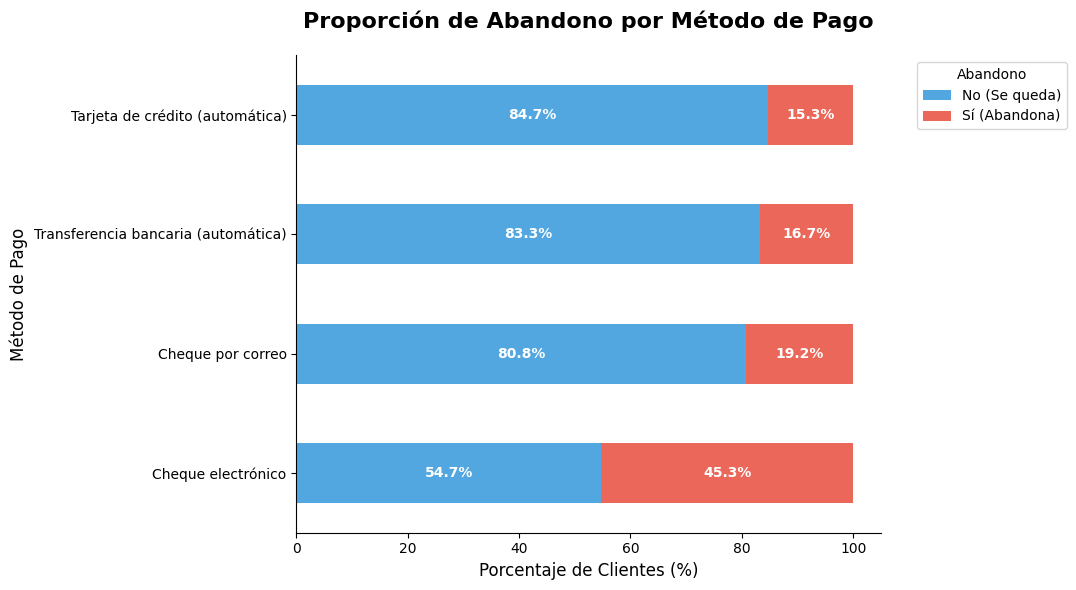

In [895]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear una tabla de contingencia (Cruce de datos)
tabla_pago = pd.crosstab(df['metodo_pago'], df['abandono'])

# Convertir a porcentajes (Normalizar al 100% por fila)
tabla_porcentajes = tabla_pago.div(tabla_pago.sum(1), axis=0) * 100

# Ordenar para que el análisis sea más claro (opcional)
tabla_porcentajes = tabla_porcentajes.sort_values(by='Sí', ascending=False)

# Crear el gráfico de barras apiladas
ax = tabla_porcentajes.plot(kind='barh', stacked=True, figsize=(11, 6),
                            color=['#3498db', '#e74c3c'], alpha=0.85)

# Estética y etiquetas
plt.title('Proporción de Abandono por Método de Pago', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Porcentaje de Clientes (%)', fontsize=12)
plt.ylabel('Método de Pago', fontsize=12)
plt.legend(title='Abandono', labels=['No (Se queda)', 'Sí (Abandona)'], bbox_to_anchor=(1.05, 1))

# Añadir los porcentajes dentro de las barras
for p in ax.patches:
    width = p.get_width()
    if width > 5: # Solo mostrar si el segmento es lo suficientemente grande
        ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2,
                f'{width:.1f}%', va='center', ha='center',
                color='white', fontweight='bold', fontsize=10)

sns.despine()
plt.tight_layout()

plt.savefig('plot(Proporción de Abandono por Método de Pago).png', dpi=300, bbox_inches='tight')

plt.show()

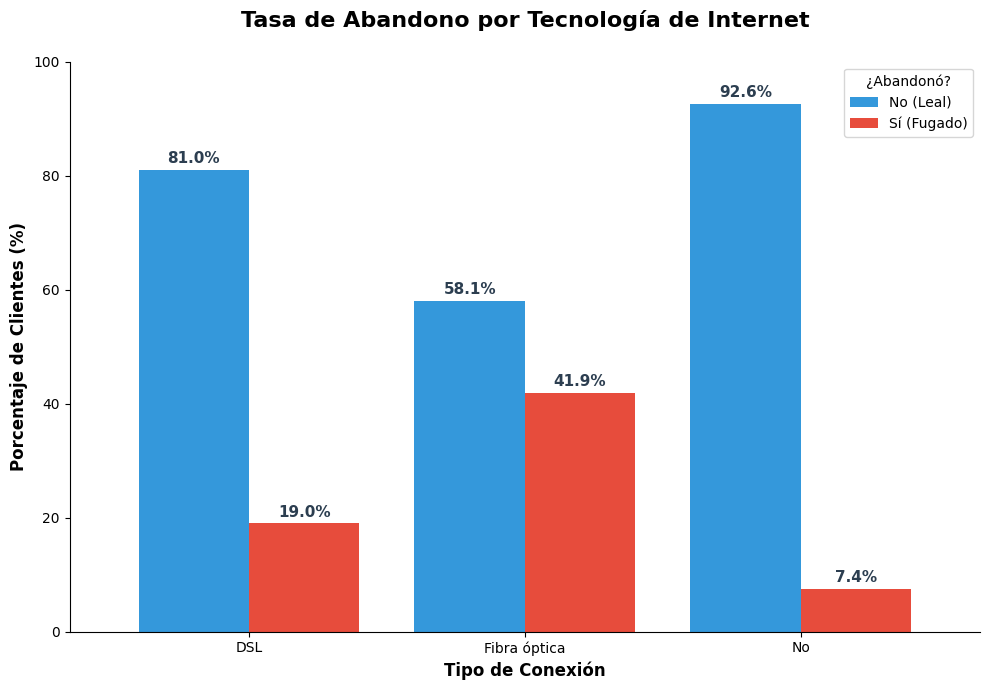

In [896]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculamos la tasa de abandono por cada tipo de internet
# Creamos una tabla cruzada de porcentajes
proporciones = pd.crosstab(df['tipo_internet'], df['abandono'], normalize='index') * 100

# Configuración del gráfico
plt.figure(figsize=(10, 7))
ax = proporciones.plot(kind='bar',
                        stacked=False,
                        color=['#3498db', '#e74c3c'],
                        ax=plt.gca(),
                        width=0.8)

# Estética profesional
plt.title('Tasa de Abandono por Tecnología de Internet', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Porcentaje de Clientes (%)', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de Conexión', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.ylim(0, 100) # El eje Y siempre al 100 para no exagerar visualmente

# Etiquetas de datos (Insights directos sobre las barras)
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.annotate(f'{height:.1f}%',
                    (x + width/2, height + 2),
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color='#2c3e50')

# Limpieza visual
sns.despine()
plt.tight_layout()
plt.legend(title='¿Abandonó?', labels=['No (Leal)', 'Sí (Fugado)'], loc='upper right')

plt.savefig('plot(Tasa de Abandono por Tecnología de Internet).png', dpi=300, bbox_inches='tight')

plt.show()

### Variables numéricas

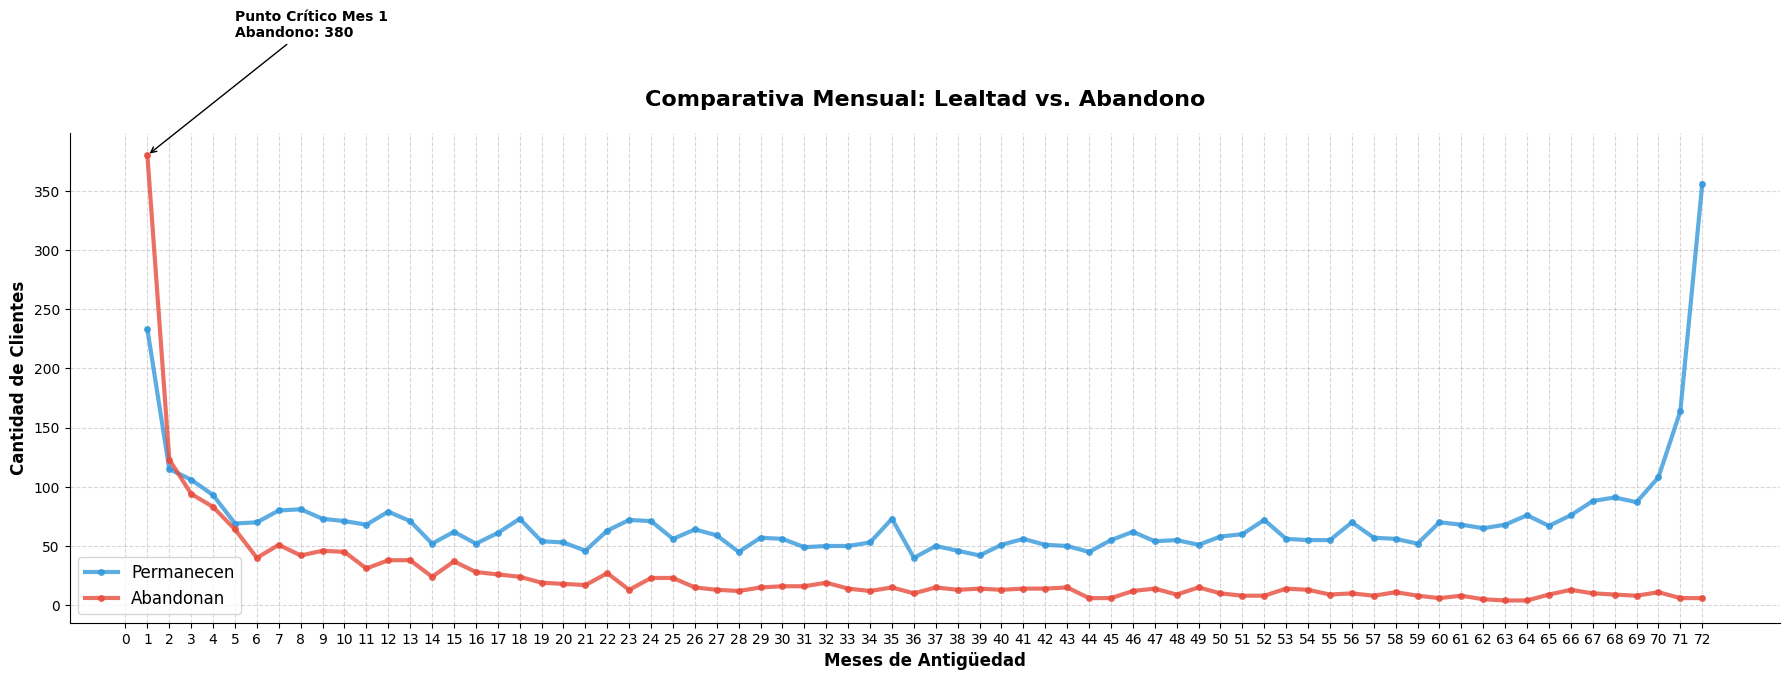

In [897]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar los datos: Contar frecuencias por mes para ambos grupos
counts_no = df[df['abandono'] == 'No']['antiguedad_meses'].value_counts().sort_index()
counts_si = df[df['abandono'] == 'Sí']['antiguedad_meses'].value_counts().sort_index()

# Configuración del gráfico
plt.figure(figsize=(18, 7))

# Línea para los que NO abandonan (Leales)
plt.plot(counts_no.index, counts_no.values, label='Permanecen',
         color='#3498db', linewidth=3, marker='o', markersize=4, alpha=0.8)

# Línea para los que SÍ abandonan (Fuga)
plt.plot(counts_si.index, counts_si.values, label='Abandonan',
         color='#e74c3c', linewidth=3, marker='o', markersize=4, alpha=0.8)

# Personalización profesional
plt.title('Comparativa Mensual: Lealtad vs. Abandono', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Meses de Antigüedad', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Clientes', fontsize=12, fontweight='bold')

# Añadir una cuadrícula sutil para facilitar la lectura
plt.grid(True, linestyle='--', alpha=0.5)

# Configurar los saltos del eje X (cada 6 meses para claridad)
plt.xticks(range(0, 73, 1))

# Resaltar puntos críticos
# Mes 1 suele ser clave en ambos
if 1 in counts_si.index and 1 in counts_no.index:
    plt.annotate(f'Punto Crítico Mes 1\nAbandono: {counts_si[1]}',
                 xy=(1, counts_si[1]), xytext=(5, counts_si[1] + 100),
                 arrowprops=dict(facecolor='black', arrowstyle='->'),
                 fontsize=10, fontweight='bold')

# Leyenda y limpieza
plt.legend(fontsize=12, frameon=True)
sns.despine()

plt.tight_layout()

plt.savefig('plot(Comparativa Mensual: Lealtad vs. Abandono).png', dpi=300, bbox_inches='tight')

plt.show()

# Matriz de Correlación

In [898]:
cols_a_limpiar = [
    'lineas_multiples', 'seguridad_online', 'respaldo_online',
    'proteccion_dispositivo', 'soporte_tecnico',
    'streaming_tv', 'streaming_peliculas'
]

mapping = {
    'Sin servicio telefónico': 'No',
    'Sin servicio de internet': 'No'
}

df_analisis = df.copy()

df_analisis[cols_a_limpiar] = df_analisis[cols_a_limpiar].replace(mapping)

cols_binarias = [
    'abandono', 'genero', 'adulto_mayor', 'tiene_pareja', 'tiene_dependientes',
    'servicio_telefono', 'lineas_multiples', 'seguridad_online',
    'respaldo_online', 'proteccion_dispositivo', 'soporte_tecnico',
    'streaming_tv', 'streaming_peliculas', 'factura_electronica'
]


df_analisis[cols_binarias] = df_analisis[cols_binarias].apply(lambda x: x.map({'Sí': 1, 'No': 0, 'Femenino': 1, 'Masculino': 0}))

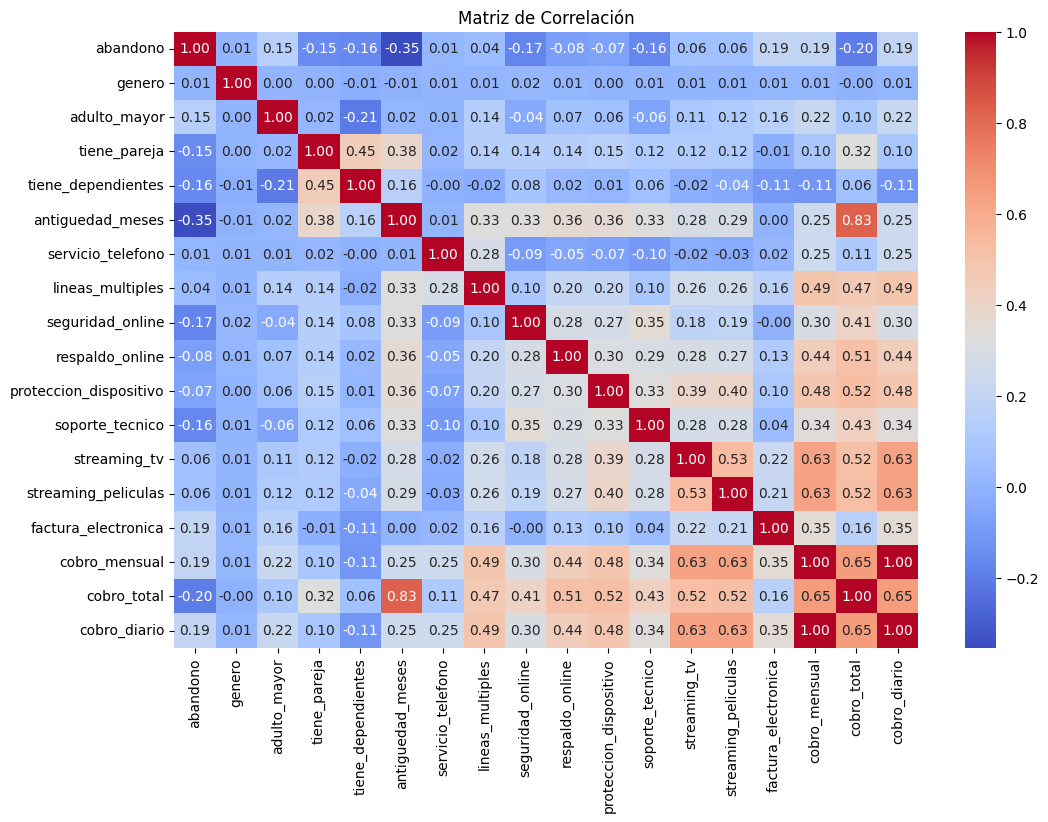

In [899]:
import seaborn as sns
import matplotlib.pyplot as plt

matriz_corr = df_analisis.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación")

plt.savefig('plot(Matriz de Correlación).png', dpi=300, bbox_inches='tight')

plt.show()

# Informe Final: Análisis de Abandono de Clientes - Telecom X


## 1. Introducción
El objetivo principal de este análisis es identificar los factores críticos que influyen en el **abandono** de clientes en Telecom X. La retención es vital para la sostenibilidad del negocio, ya que el costo de adquirir un nuevo cliente suele ser superior al de mantener a uno actual. A través de este estudio, buscamos transformar datos brutos en insights accionables para reducir la tasa de evasión.

## 2. Limpieza y Tratamiento de Datos
Para garantizar la integridad técnica y la interpretabilidad de los hallazgos, se ejecutaron los siguientes procedimientos:

* **Traducción y Estandarización:** Se renombraron las 21 columnas del dataset al español y se tradujeron los valores categóricos. La variable `adulto_mayor` se recodificó de formato numérico (0/1) a categórico (No/Sí).
* **Tratamiento de Datos Faltantes:** Se detectaron espacios vacíos en `cobro_total` y `abandono`, convirtiéndolos en nulos (NaN) y eliminando dichas filas para no sesgar los promedios financieros.
* **Corrección de Tipos:** Se ajustó `cobro_total` a formato flotante (`float64`).
* **Validación de Consistencia:** Se confirmó la inexistencia de duplicados y se validó que no hubiera inconsistencias lógicas entre los servicios contratados.


## 3. Análisis Exploratorio de Datos (EDA)
Mediante la segmentación de variables, se identificaron los puntos donde el riesgo de abandono es crítico:

![Gráfico: Impacto total del abandono](https://raw.githubusercontent.com/iesvs-campi/oracle-one-challenge-telecom-x-1/main/plots/impacto_total_churn.png)

* **Contratos y Fidelidad:** Los clientes con contratos **"Mes a mes"** presentan una tasa de abandono del **42.71%**, mientras que el compromiso a largo plazo (2 años) reduce esta cifra drásticamente al **2.85%**.

![Gráfico: Relación entre el tipo de contrato y el abandono](https://raw.githubusercontent.com/iesvs-campi/oracle-one-challenge-telecom-x-1/main/plots/impacto_tipo_contrato_churn.png)

* **Tecnología de Internet:** El segmento de **Fibra óptica** es el más vulnerable con un **41.89%** de abandono, lo que representa más del doble de la tasa observada en usuarios de DSL (19%).

![Gráfico: Tasa de abandono por tecnología de internet](https://raw.githubusercontent.com/iesvs-campi/oracle-one-challenge-telecom-x-1/main/plots/impacto_tipo_conexion_churn.png)

* **Análisis de Antigüedad y Tendencia:** El riesgo de abandono es extremadamente alto al inicio de la relación comercial. Se observa un **pico crítico de 380 abandonos en el primer mes de servicio**, tendencia que disminuye significativamente conforme aumenta la antigüedad del cliente.

![Gráfico: Distribución de cobro mensual vs abandono](https://raw.githubusercontent.com/iesvs-campi/oracle-one-challenge-telecom-x-1/main/plots/impacto_mensual_churn.png)

## 4. Conclusiones e Insights
1. **Vulnerabilidad en Fibra Óptica:** Casi la mitad de los usuarios de fibra abandonan la empresa, sugiriendo una posible insatisfacción con la relación precio-calidad.
2. **Efecto de los Métodos de Pago:** Los métodos de pago manuales (como el cheque electrónico) muestran una correlación directa con el abandono en comparación con los pagos automáticos.
   
![Gráfico: Impacto del método de pago en el abandono](https://raw.githubusercontent.com/iesvs-campi/oracle-one-challenge-telecom-x-1/main/plots/impacto_metodo_pago_churn.png)

3. **Periodo Crítico:** La falta de antigüedad (`antiguedad_meses`) combinada con contratos mensuales genera el perfil de mayor riesgo para la compañía.

## 5. Recomendaciones Estratégicas
* **Migración Contractual:** Incentivar la transición de contratos mensuales a anuales mediante bonificaciones de lealtad o descuentos progresivos.
* **Optimización de Fibra:** Realizar una auditoría técnica y comercial sobre el servicio de fibra óptica para identificar las causas de la alta tasa de fuga (41.89%) y ajustar la propuesta de valor.
* **Promoción de Pagos Automáticos:** Implementar campañas que fomenten el registro de tarjetas de crédito o transferencias automáticas para reducir la fricción del pago manual mensual.

---
**Nota final:** Este informe resume el proceso de transformación de datos y proporciona la base estratégica para que Telecom X implemente medidas de retención proactivas.

# Export csv

In [900]:
df.rename(columns={'abandono':'Churn'},inplace=True)

In [903]:
df.to_csv("datos_tratados.csv", index=False)

In [902]:
ruta_telecom_2 = '/content/drive/MyDrive/ONE/6. Estadisticas y Machine Learning/8. Telecom X: análisis de evasión de clientes - Parte 2'
df.to_csv(ruta_telecom_2 + '/datos_tratados.csv', index=False)